In [24]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import scipy.io as io
import argparse
import sys
from pathlib import Path
from tqdm import tqdm

import src.utils.utils as utils
# import src.training.training as training
import src.utils.extractor as extractor
import src.models.models as models
import src.models.foundation_models as rsfm

if torch.cuda.is_available():
    dev = "cuda:0"
    torch.set_default_device(dev)
    print(f"Using device: {dev}")
    
elif torch.backends.mps.is_available():
    dev = torch.device("mps")
    torch.set_default_device(dev)
    print(f"Using device: {dev}")
    
else:
    dev = "cpu"
    print(f"Using device: {dev}")

Using device: cuda:0


In [25]:
dataset = "jasper"
data = io.loadmat(f"datasets/{dataset}.mat")
Y_flat = torch.tensor(data["Y"], dtype=torch.float32)
Y_flat = utils.normalize(Y_flat)
E = torch.tensor(data["E"])
A_flat = torch.tensor(data["A"])
B, c, N = E.shape[0], E.shape[1], Y_flat.shape[1]

Y = utils.oneD_to_2d(Y_flat)
A = utils.oneD_to_2d(A_flat)
H = Y.shape[-1]
Y = Y.to(torch.float32)
Y = Y.unsqueeze(0)

global_path = str(Path.cwd().parent)
with open(f"{global_path}/SS-HSU_benchmark/datasets/{dataset}_wavelength.txt", "r") as file:
    lines = file.readlines()
    wavelengths = [float(line.strip()) for line in lines if line.strip()]

In [26]:
n_features  = 1
use_cls     = False
extend_cls  = False
fm_name     = "DOFA"
n_features  = 4 if fm_name == "HyperSIGMA" else n_features
patch_size  = 16

if fm_name == "DOFA":
    if H < 224:
        Y = F.interpolate(Y, size=(224,224))
        new_H = 224
    else:
        new_H = 224
    Y = Y[:,:,:224, :224]
    fm = rsfm.create_fm(fm_name, Y, n_features=n_features, use_cls=use_cls, extend_cls=extend_cls, path=global_path)
    features = rsfm.get_dofa_features(fm, Y, wavelengths)
    if use_cls:
        D = features.shape[-1]
    else:
        D = int(features.shape[0]/n_features)
        
elif fm_name == "HyperFree":
    n_features = 1
    use_cls = False
    n_patches = H//patch_size
    if n_patches%2 != 0:
        H = (n_patches-1)*patch_size + patch_size-1
    Y = Y[:, :, :H, :H]
    fm = rsfm.create_fm(fm_name, Y, patch_size=patch_size, path=global_path)
    features = rsfm.get_hyperfree_features(fm, Y, wavelengths)
    D = features.shape[0]

elif fm_name == "HyperSIGMA":
    fm = rsfm.create_fm(fm_name, Y, c, path=global_path)
    features = rsfm.get_hypersigma_features(fm, Y)
    D = int(features.shape[1]/n_features)

elif fm_name == "SpecViT":
    if H < 128:
        Y = F.interpolate(Y, size=(128,128))
        new_H = 128
    else:
        new_H = 128
    Y = Y[:,:,:128, :128]
    fm = rsfm.create_fm(fm_name, Y, path=global_path)
    features = rsfm.get_specvit_features(fm, Y, use_cls)
    if use_cls:
        D = features.shape[-1]
    else:
        D = features.shape[0]

else:
    pass

print(f"features: {features.shape}")

if fm_name == "DOFA":
    alpha = int(features.shape[1]**0.5)
    unmixer = rsfm.Unmixing_from_features(D=D, alpha=alpha, B=B, c=c, n_features=n_features, use_cls=use_cls)

elif fm_name == "HyperFree":
    alpha = int(features.shape[1]**0.5)
    unmixer = rsfm.Unmixing_from_features(D=D, alpha=alpha, B=B, c=c, H=H, n_features=n_features, use_cls=use_cls)

elif fm_name == "HyperSIGMA":
    patch_size = 64
    unmixer = rsfm.Unmixing_from_features(D=D, B=B, c=c, H=patch_size, n_features=n_features, hypersig=True)

elif fm_name == "SpecViT":
    alpha = int(features.shape[1]**0.5)
    unmixer = rsfm.Unmixing_from_features(D=D, alpha=alpha, H=new_H, B=B, c=c, use_cls=use_cls)

else:
    pass

features: torch.Size([768, 196])


The unmixer model has :  9.89 M trainable params
upsample.0.weight :  9834.50 k params
upsample.0.bias :  50.18 k params
abundance_estimator.0.weight :  3.07 k params
abundance_estimator.0.bias :  0.00 k params
abundance_estimator.2.weight :  0.00 k params
abundance_estimator.2.bias :  0.00 k params
decoder.decoder.weight :  0.79 k params


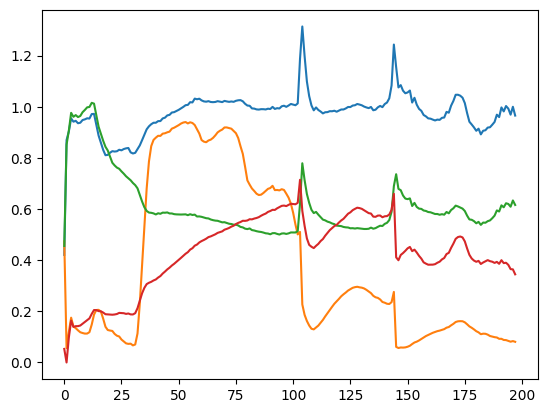

In [27]:
model = unmixer
model.apply(model.weights_init)
model = models.init_decoder_weights(model, Y, c, is_unmixer=True, use_sivm=True)

# for param in model.abundance_estimator.parameters():
#     param.requires_grad = False
    
print("The unmixer model has : ", format(sum(p.numel() for p in model.parameters() if p.requires_grad)/1e6, '.2f'), "M trainable params")
for name, param in model.named_parameters():
    if param.requires_grad:
        print(name, ': ', format(param.numel()/1e3, '.2f'), "k params")

E_hat, A_hat, Y_hat = model(features)
plt.plot(E_hat.detach().cpu())

In [ ]:
train_losses, sad_losses, ab_losses, tv_e_losses, tv_a_losses, mse_losses = [], [], [], [], [], []
loader, _, _ = utils.create_dataloader(dataset, patch_size=H, dev=dev, path=global_path+"/SS-HSU_benchmark/datasets/")

epochs, lr = 400, 0.01
optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

for epoch in range(epochs):
    
    train_loss, sad_loss, ab_loss, tv_e_loss, tv_a_loss, mse_loss = 0, 0, 0, 0, 0, 0
    
    for Y, E, A in loader:
        optimizer.zero_grad()
        
        Y = utils.oneD_to_2d(Y).to(dev)
        A = utils.oneD_to_2d(A).to(dev)
        E = E.to(dev)

        if fm_name == "DOFA":
            if Y.shape[-1] < new_H:
                Y = F.interpolate(Y, size=(new_H,new_H))
            Y = Y[:,:,:new_H, :new_H]
            Y_flat = Y.reshape(1, B, new_H**2)
            
            if A.shape[-1] < new_H:
                A = F.interpolate(A, size=(new_H,new_H))
            A = A[:,:,:new_H, :new_H]
            A_flat = A.reshape(1, c, new_H**2)

            features = rsfm.get_dofa_features(fm, Y, wavelengths)
            noise = torch.rand_like(features)
            E_hat, A_hat, Y_hat = model(features)

        elif fm_name == "HyperFree":
            features = rsfm.get_hyperfree_features(fm, Y, wavelengths)
            noise = torch.rand_like(features)
            E_hat, A_hat, Y_hat = model(features)

        elif fm_name == "HyperSIGMA":
            E_hat, A_hat, Y_hat = rsfm.unmix_full_image_hypersigma(Y, model, fm, c, use_bn=True)

        elif fm_name == "SpecViT":
            if Y.shape[-1] < new_H:
                Y = F.interpolate(Y, size=(new_H,new_H))
            Y = Y[:,:,:new_H, :new_H]
            Y_flat = Y.reshape(1, B, new_H**2)
            
            if A.shape[-1] < new_H:
                A = F.interpolate(A, size=(new_H,new_H))
            A = A[:,:,:new_H, :new_H]
            A_flat = A.reshape(1, c, new_H**2)

            features = rsfm.get_specvit_features(fm, Y, use_cls)
            noise = torch.rand_like(features)
            E_hat, A_hat, Y_hat = model(features)

        else:
            pass
        
        W_ab, W_tv_e, W_mse, W_tv_a, W_e = 0.5, 1e-3, 0.2, 1e-7, 0#1, 0.5, 1e-2, 0.2, 0
        loss, loss_sad, loss_ab, loss_tv_e, loss_tv_a, loss_mse, loss_norm_e = model.loss(Y, Y_hat, A_hat, E_hat, W_sad=1, W_ab=W_ab, W_tv_e=W_tv_e, W_mse=W_mse, W_tv_a=W_tv_a, W_e=W_e)
        train_loss += loss.item()
        sad_loss += loss_sad.item()
        ab_loss += loss_ab.item()
        tv_e_loss += loss_tv_e.item()
        tv_a_loss += loss_tv_a.item()
        mse_loss += loss_mse.item()

        if epoch%(epochs//10)==0:
            print(f"Epoch {epoch}: total = {format(loss, '.3f')}, SAD = {format(loss_sad, '.3f')}, MSE = {format(loss_mse, '.3f')}, Ab = {format(loss_ab, '.3f')}, TV_E = {format(tv_e_loss, '.3f')}, TV_A = {format(loss_tv_a, '.3f')}, Norm_e = {format(loss_norm_e, '.3f')}")
        
        loss.backward()
        optimizer.step()
        
        with torch.no_grad():
            constraints = models.weightConstraint()
            model.decoder.apply(constraints)
        break

    train_loss /= len(loader)
    sad_loss /= len(loader)
    ab_loss /= len(loader)
    tv_e_loss /= len(loader)
    tv_a_loss /= len(loader)
    mse_loss /= len(loader)
    train_losses.append(train_loss)
    sad_losses.append(sad_loss)
    ab_losses.append(ab_loss)
    tv_e_losses.append(tv_e_loss)
    tv_a_losses.append(tv_a_loss)
    mse_losses.append(mse_loss)
fig = utils.plot_losses(train_losses, sad_losses, ab_losses, tv_e_losses, mse_losses)

Epoch 0: total = 1.182, SAD = 0.493, MSE = 0.200, Ab = 0.239, TV_E = 0.243, TV_A = 0.006, Norm_e = 0.000


In [ ]:
# import numpy as np

# E_hat_np = E_hat.detach().cpu().numpy()
# A_hat = np.linalg.pinv(E_hat_np) @ Y[0].reshape(B, 224**2).detach().cpu().numpy()
# A_hat = A_hat.reshape(c, 224, 224)
# im = plt.imshow(A_hat[5])
# plt.colorbar(im)

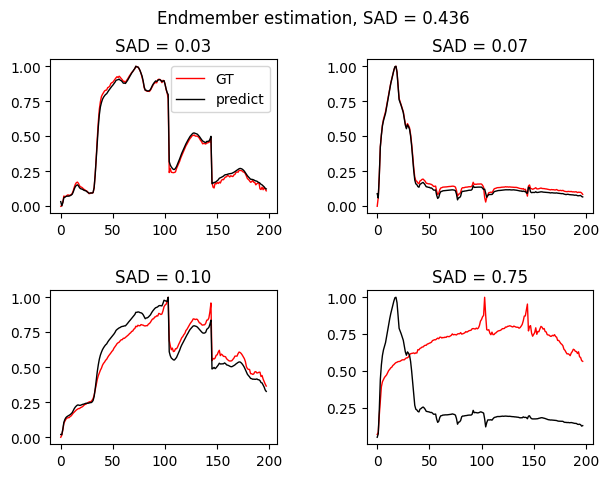

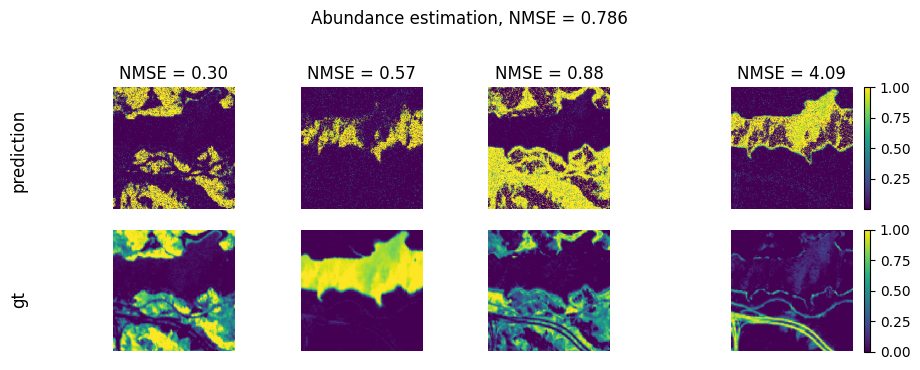

In [ ]:
if fm_name == "DOFA" or fm_name == "HyperFree" or fm_name == "SpecViT":
    E_hat, A_hat, Y_hat = model(features)
    E_hat2, A_hat2, Y_hat2 = model(features)

else:
    E_hat, A_hat, Y_hat = rsfm.unmix_full_image_hypersigma(Y, model, fm, c, patch_size=patch_size, use_bn=True)
    
utils.plot_results(E_hat, A_hat, A, E, normalize_E=True, normalize_A=True)
E_hat, _, A_hat, _ = utils.order_endmembers(E, E_hat, A_hat)

In [ ]:
diff = A_hat - A_hat2
mean = (A_hat + A_hat2)/2
plt.imshow(A_hat[0].detach().cpu())

A_hat2 = torch.stack([A_hat2[0, 1], A_hat2[0, 2], A_hat2[0, 0], A_hat2[0, 3]], dim=0)
utils.compare_hsis(A_hat, A_hat2)

In [ ]:
sys.path.append("/home/ids/edabier/HSU/IEEE_TPAMI_SpectralGPT")
import models_mae_spectral

torch.serialization.add_safe_globals([argparse.Namespace])
state_dict = torch.load("/home/ids/edabier/HSU/IEEE_TPAMI_SpectralGPT/data/SpectralGPT+.pth", map_location=dev)["model"]

img_size = 128
spectral_gpt = models_mae_spectral.mae_vit_base_patch8_128(num_frames=Y.shape[0], pred_t_dim=Y.shape[0])
# spectral_gpt = models_mae_spectral.__dict__[f"mae_vit_base_patch{patch_size}_{img_size}"]()

encoder_keys = [k for k in state_dict.keys() if k.startswith('patch_embed') or k.startswith('blocks') or k.startswith('norm')]
encoder_state_dict = {k: state_dict[k] for k in encoder_keys}
spectral_gpt.load_state_dict(encoder_state_dict, strict=False)

y_patch = Y.unsqueeze(0)[:,:,:img_size,:img_size]
# y_patch = y_patch.reshape(Y.shape[0], 1, img_size, img_size)
# print(y_patch.shape)
# y_patch = y_patch.reshape(y_patch.shape[0], y_patch[2], y_patch[1], y_patch[3])
latent, _, _ = spectral_gpt.forward_encoder(y_patch, mask_ratio=0.0)

In [ ]:
sys.path.append("/home/ids/edabier/HSU/HyperFree")
from HyperFree import build_HyperFree_vit_b, predictor

pred = build_HyperFree_vit_b(checkpoint="/home/ids/edabier/HSU/HyperFree/data/HyperFree-b.pth", image_size=batched_Y.shape[2], vit_patch_size=patch_size)
hyperfree = predictor.HyperFree_Predictor(pred)

input_y = hyperfree.transform.apply_image_torch(batched_Y)
hyperfree.set_torch_image(input_y, original_image_size=(Y.shape[1], Y.shape[2]), spectral_lengths=wavelengths, GSD=GSD)
hyperfree.features.shape